In [1]:
import pandas as pd
import math
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pickle
from haversine import haversine, Unit
from heapq import heappop, heappush
import geopandas as gpd

# Import customized functions
from merge_bus_subway import merge_subway_bus
from compute_shortest_paths_two_layer import compute_shortest_path


In [2]:
# %matplotlib widget
# %matplotlib qt

In [3]:
# Import transport networks

weekday_subway_network = pickle.load(open('subway_network_weekday.pickle', 'rb'))
weekend_subway_network = pickle.load(open('subway_network_weekend.pickle', 'rb'))
weekday_bus_network = pickle.load(open('bus_network_weekday.pickle', 'rb'))
weekend_bus_network = pickle.load(open('bus_network_weekend.pickle', 'rb'))

G_merged_weekday = merge_subway_bus(weekday_subway_network, weekday_bus_network, 0.5)
G_merged_weekend = merge_subway_bus(weekend_subway_network, weekend_bus_network, 0.5)

In [4]:
# Import the zipcode to doctor travel information

data = pd.read_csv(r"C:\Users\baodu\Dropbox\Summer_research_2024\accessibility_all.csv")
data_28_4mins = data[data['Travel_Time']<=28.4]

In [5]:
# Import the geo information of NYC

geoloc_nyc = gpd.read_file('geoloc_nyc.shp')
geoloc_nyc['centroid'] = geoloc_nyc.geometry.centroid

zipcode_population = gpd.read_file(r"C:\Users\baodu\Dropbox\Summer_research_2024\ZIP_CODE_040114\ZIP_CODE_040114.shp")

zipcode_population_dict = {row.ZIPCODE : row.POPULATION for row in zipcode_population.itertuples()}

lst = []
for row in geoloc_nyc.itertuples():
    zcta5 = row.ZCTA5
    lst.append(zipcode_population_dict[zcta5])

geoloc_nyc['population'] = lst

C:\Users\baodu\AppData\Local\Temp\ipykernel_13452\2951398676.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geoloc_nyc['centroid'] = geoloc_nyc.geometry.centroid


In [6]:
# Function to find which zipcode residents are accessible for each doctor (doctor_zipcode)
# Find the number of shared zipcodes for every pair of doctors

def doctor_matrix(data):
    doctor_lst = data['Doctor'].unique()
    zipcode_lst = data['Zipcode'].unique()

    # which zipcode residents are accessible for each doctor (doctor_zipcode)
    doctor_zipcode = pd.DataFrame(0, index=doctor_lst, columns=zipcode_lst)

    for row in data.itertuples(index=False):
        doctor_zipcode.loc[row.Doctor, row.Zipcode] = 1
        
    doctor_doctor = pd.DataFrame(0, index=doctor_lst, columns=doctor_lst)

    # Use matrix multiplication to find the number of shared zipcodes for every pair of doctors
    doctor_doctor = doctor_zipcode.dot(doctor_zipcode.T)
    return doctor_zipcode, doctor_doctor

In [7]:
doctors_pos={}
nyc_doctor = pd.read_csv(r'C:\Users\baodu\Dropbox\Summer_research_2024\nyc_doctor_review.csv', encoding='unicode_escape')
nyc_doctor = nyc_doctor.dropna(subset=['Latitude', 'Longitude','Site_Name'])

for index, row in nyc_doctor.iterrows():
    curr = row['count']
    # extract vaild rows only
    if isinstance(curr, int) or (isinstance(curr, str) and curr.isnumeric()):
        doctors_pos[int(row['index'])] = (float(row['Latitude']), float(row['Longitude']))

# Reverse the longitude and latitude's position in the dict
for key, val in doctors_pos.items():
    reversed_val = val[::-1]
    doctors_pos[key] = reversed_val

C:\Users\baodu\AppData\Local\Temp\ipykernel_13452\539216722.py:2: DtypeWarning: Columns (0,1,2,5,6,12,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,61,63,65,67,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,134,137,138,139,140,141,142,143,144,145,147,149,154,155,156,157,162,163,164,165,166,168,169,170,171,172,173,174,175,176,177,182,183,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,2

In [8]:
def plot_doctor_network(matrix_df):
    matrix = matrix_df.values

    G = nx.Graph()

    doctors = matrix_df.index.tolist()
    G.add_nodes_from(doctors)

    # Add edges with weights (number of shared zipcodes)
    for i, doctor1 in enumerate(doctors):
        for j, doctor2 in enumerate(doctors):
            if i < j:  # To avoid adding edges twice
                weight = matrix[i, j]
                if weight > 0:  # Only add edges with weight > 0
                    G.add_edge(doctor1, doctor2)


    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G, weight='weight')
    
    # print("Degree Centrality:", degree_centrality)
    # print("Betweenness Centrality:", betweenness_centrality)
    nx.set_node_attributes(G, doctors_pos, 'pos')
    # plt.figure(figsize=(15,10))
    fig, ax = plt.subplots(figsize=(20, 15))
    geoloc_nyc.plot(ax=ax, color='lightgrey', edgecolor='black')

    nx.draw(G, pos=doctors_pos, ax=ax, with_labels=False, node_size=6, node_color='green', font_size=9)
    plt.title("Doctor Accessibility Network Based on Shared Patients")
    plt.show()
    
    return G


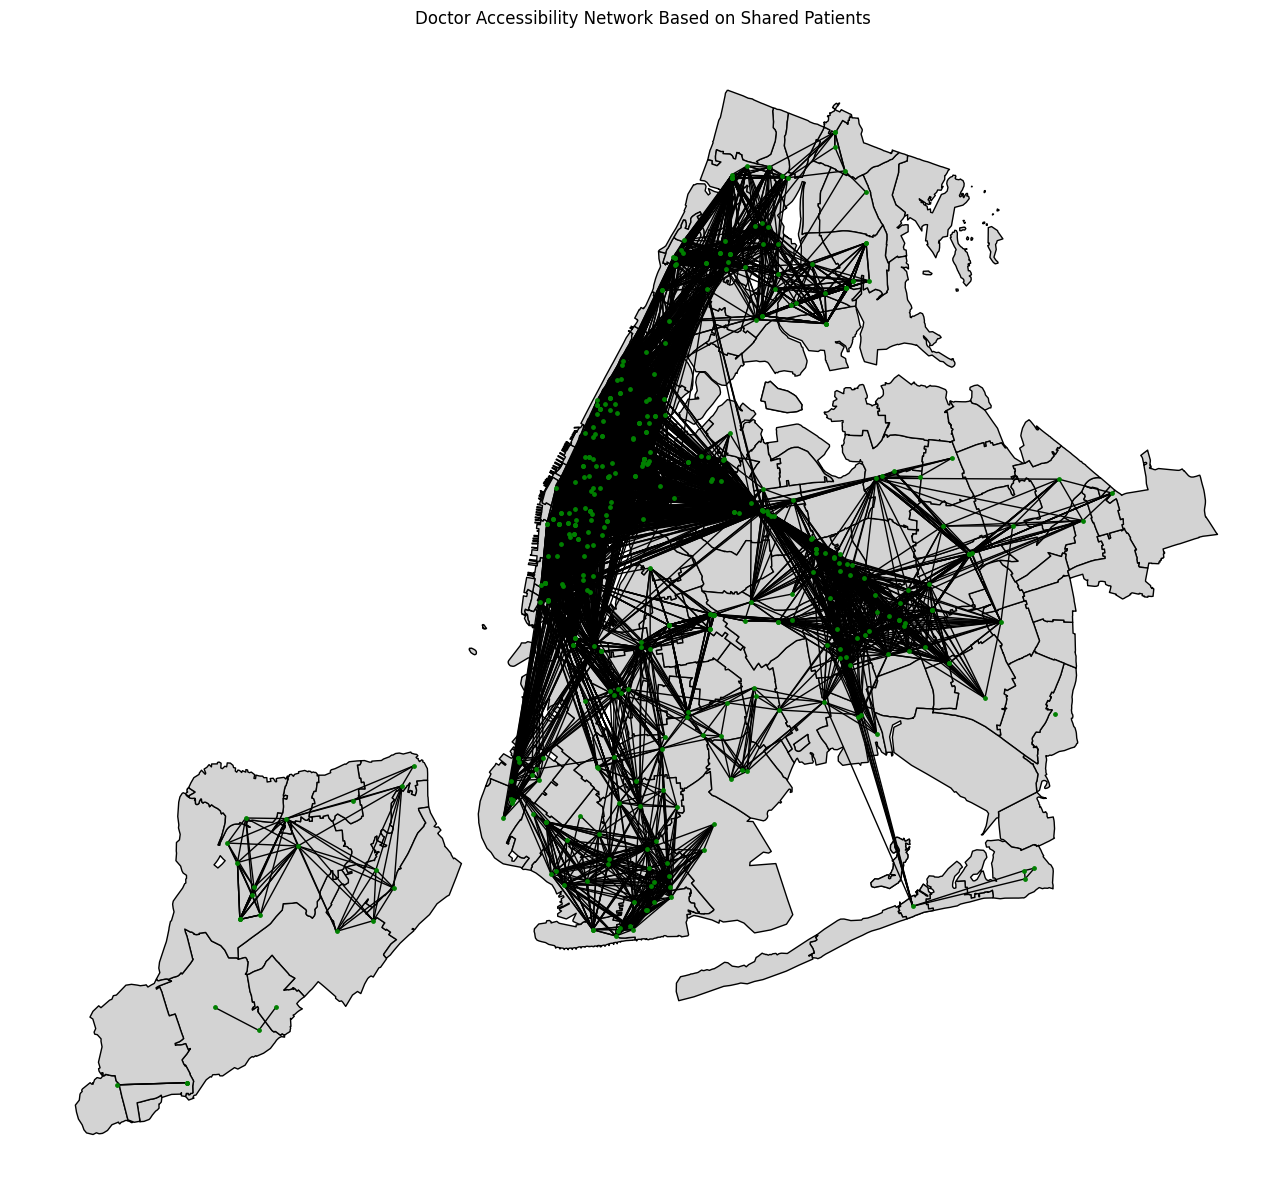

In [10]:
matrix28_4mins = doctor_matrix(data_28_4mins)[1]

G_28_4mins = plot_doctor_network(matrix28_4mins)

In [11]:
doctor_zipcode = doctor_matrix(data_28_4mins)[0]

result_dict = {}
for idx, row in doctor_zipcode.iterrows():
    result_dict[idx] = [col for col in doctor_zipcode.columns if row[col] == 1]

# Find the degree of doctors in the doctor network
doctor_degree = {key : len(val) for key, val in result_dict.items()}


nx.set_node_attributes(G_28_4mins, doctor_degree, 'degree')
pickle.dump(G_28_4mins, open(f'Doctor_Network.pickle', 'wb'))

df_doctor_degree = pd.DataFrame(doctor_degree.items(), columns=['id','degree'])
df_doctor_degree.to_csv('doctor_degree.csv')


# Find how many residents are accessible for each doctor
accessible_residents_doctor = {}

for key, val in result_dict.items():
    population = 0
    for i in val:
        population += zipcode_population_dict[str(i)]
    accessible_residents_doctor[key] = population

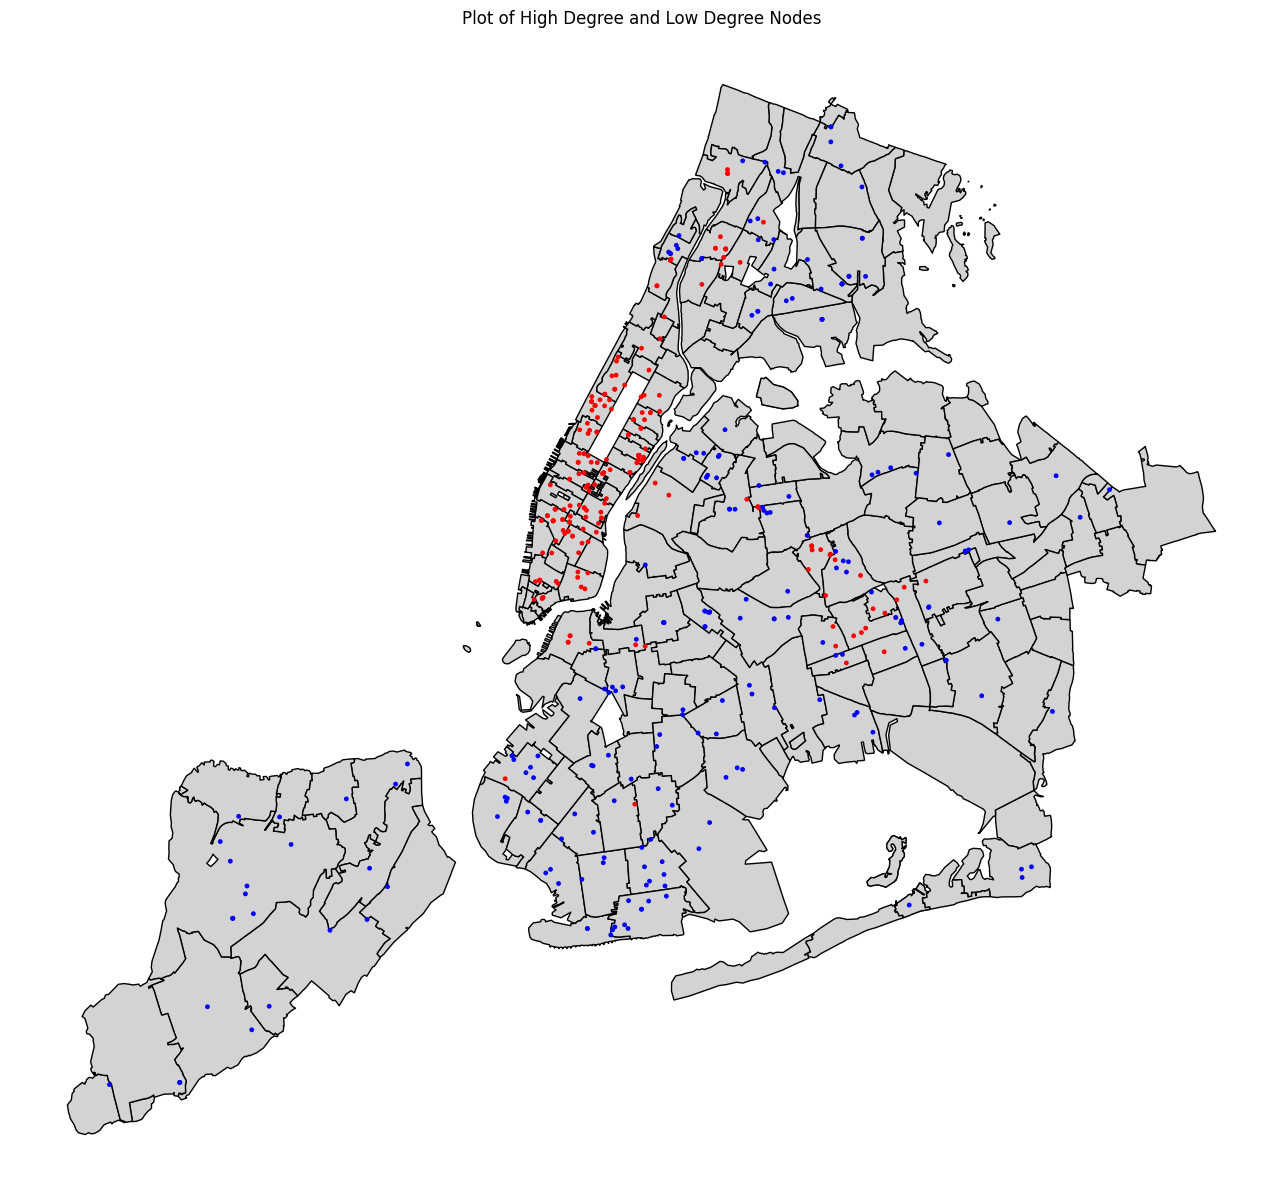

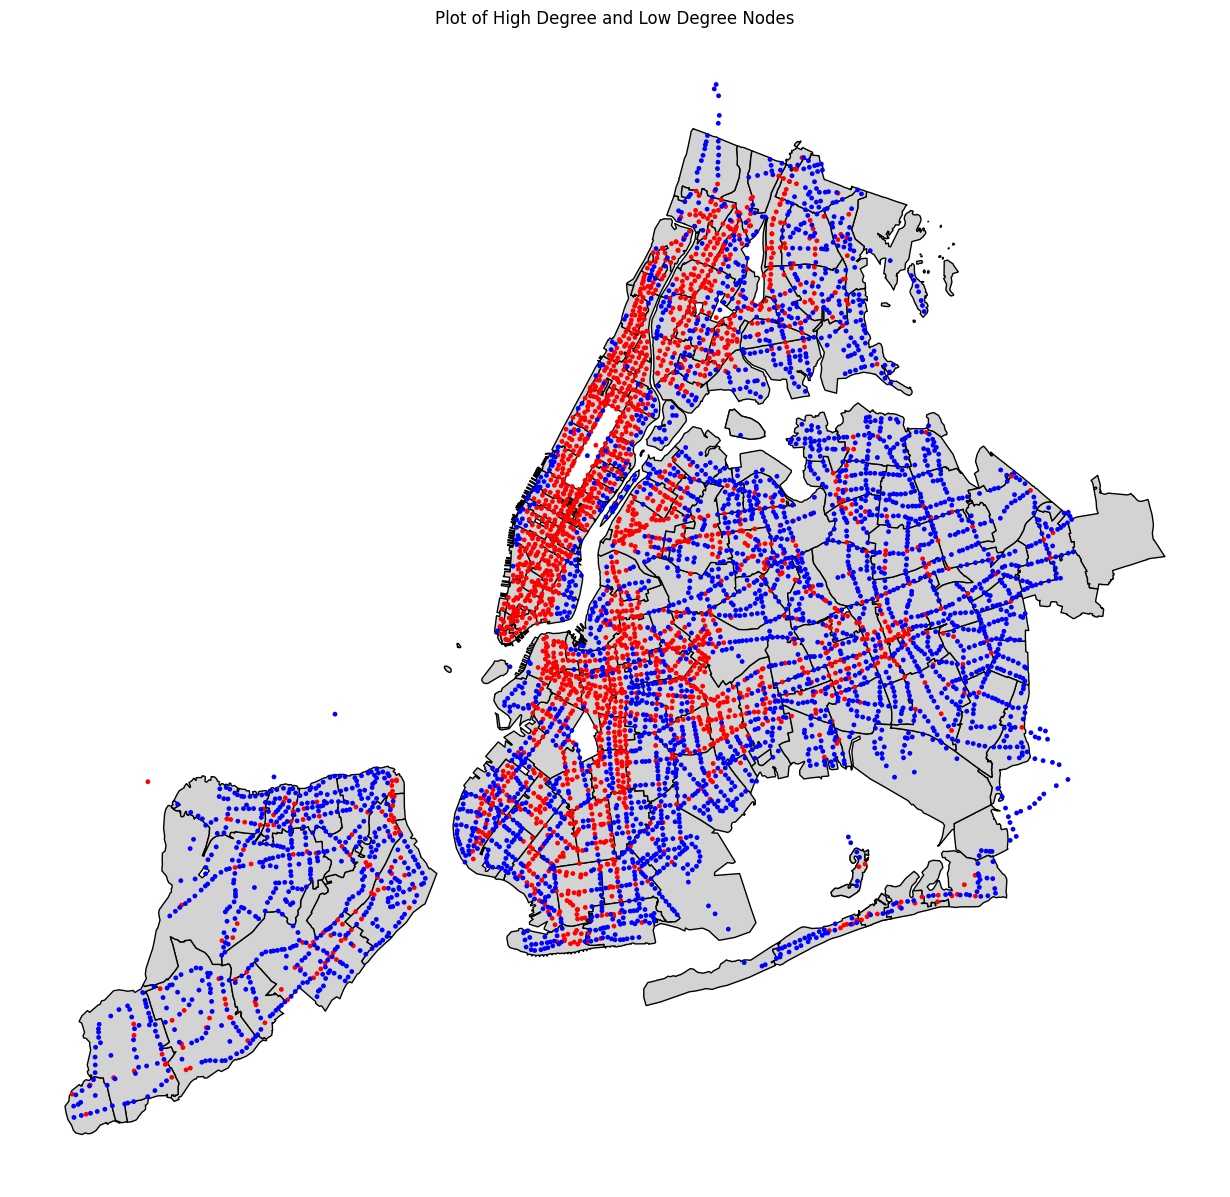

In [12]:
degree_centrality = nx.degree_centrality(G_28_4mins)

# accessible_residents_doctor = {k: v for k, v in sorted(accessible_residents_doctor.items(), key=lambda item: item[1])}
degree_centrality = {k: v for k, v in sorted(degree_centrality.items(), key=lambda item: item[1])}

def plot_high_low_degree_nodes(degree_dict, node_pos):
    degree_dict = {k: v for k, v in sorted(degree_dict.items(), key=lambda item: item[1])}

    keys = list(degree_dict.keys())

    new_G = nx.Graph()

    median = degree_dict[keys[len(keys)//2]]

    low = [key for key, val in degree_dict.items() if degree_dict[key] <= median]
    high = [key for key, val in degree_dict.items() if degree_dict[key] > median]

    new_G.add_nodes_from(high)
    new_G.add_nodes_from(low)
    
    node_colors=[]

    for i in new_G.nodes():
        if i in low:
            node_colors.append('blue')
        elif i in high:
            node_colors.append('red')
            
    fig, ax = plt.subplots(figsize=(20, 15))
    geoloc_nyc.plot(ax=ax, color='lightgrey', edgecolor='black')
    nx.draw(new_G, pos=node_pos, ax=ax, node_color=node_colors, with_labels=False, labels=degree_dict, node_size=6, font_size=9, verticalalignment='bottom')
    plt.title("Plot of High Degree and Low Degree Nodes")


station_degrees = {node : degree for node, degree in G_merged_weekday.degree}
station_pos = nx.get_node_attributes(G_merged_weekday,'pos')

# Plot the distribution of high degree and low degree nodes for doctor and stations
plot_high_low_degree_nodes(degree_centrality, doctors_pos)
plot_high_low_degree_nodes(station_degrees, station_pos)

175


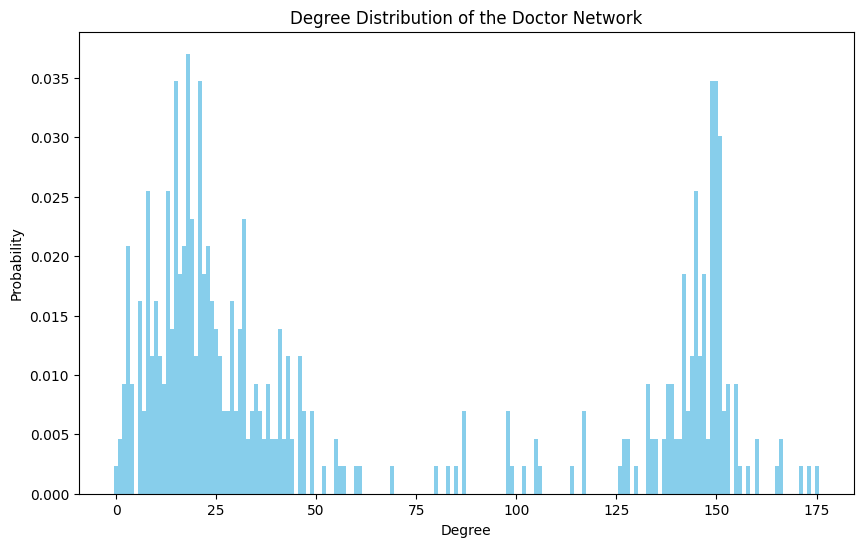

86


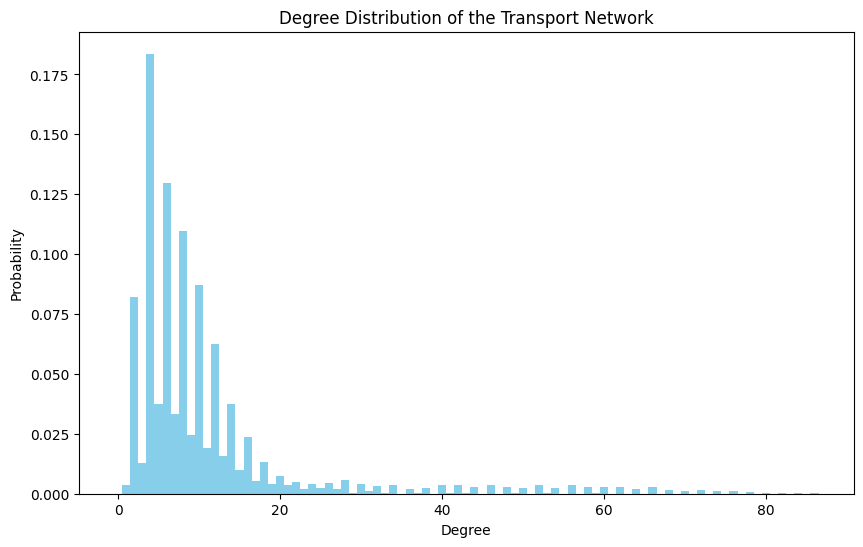

In [13]:
def plot_degree_dist(G, title):
    degrees = [degree for node, degree in G.degree()]
    print(max(degrees))
    # print(len(degrees))
    degree_counts = np.bincount(degrees)
    degree_probabilities = degree_counts / sum(degree_counts)

    plt.figure(figsize=(10, 6))
    plt.bar(range(len(degree_probabilities)), degree_probabilities, width=1, color='skyblue')
    # plt.bar(range(len(degrees)), degrees, width=0.8, color='skyblue')
    plt.xlabel('Degree')
    plt.ylabel('Probability')
    plt.title(title)
    plt.show()

plot_degree_dist(G_28_4mins, 'Degree Distribution of the Doctor Network')
plot_degree_dist(G_merged_weekday, 'Degree Distribution of the Transport Network')

In [16]:
def node_edge_comparsion(G_transport, G_doctor):
    print(f'The doctor network has {len(list(G_doctor.nodes))} nodes and {len(list(G_doctor.edges))} edges')
    print(f'The transport network has {len(list(G_transport.nodes))} nodes and {len(list(G_transport.edges))} edges')
    
# node_edge_comparsion(G_merged_weekday, G_50mins)

In [17]:
# Spectral clustering
from sklearn.cluster import SpectralClustering

# Function to perform spectral clustering
def spectral_clustering(adjacency_matrix, n_clusters):
    # adjacency_matrix = matri
    # print(adjacency_matrix)
    sc = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', assign_labels='kmeans')
    labels = sc.fit_predict(adjacency_matrix)
    
    return labels

n_clusters_doctor = 7
n_clusters_transport = 7

# Perform spectral clustering
labels_doctor = spectral_clustering(matrix28_4mins, n_clusters_doctor)
labels_transport = spectral_clustering(nx.to_numpy_array(G_merged_weekday), n_clusters_transport)


C:\Users\baodu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\manifold\_spectral_embedding.py:301: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
C:\Users\baodu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\baodu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found

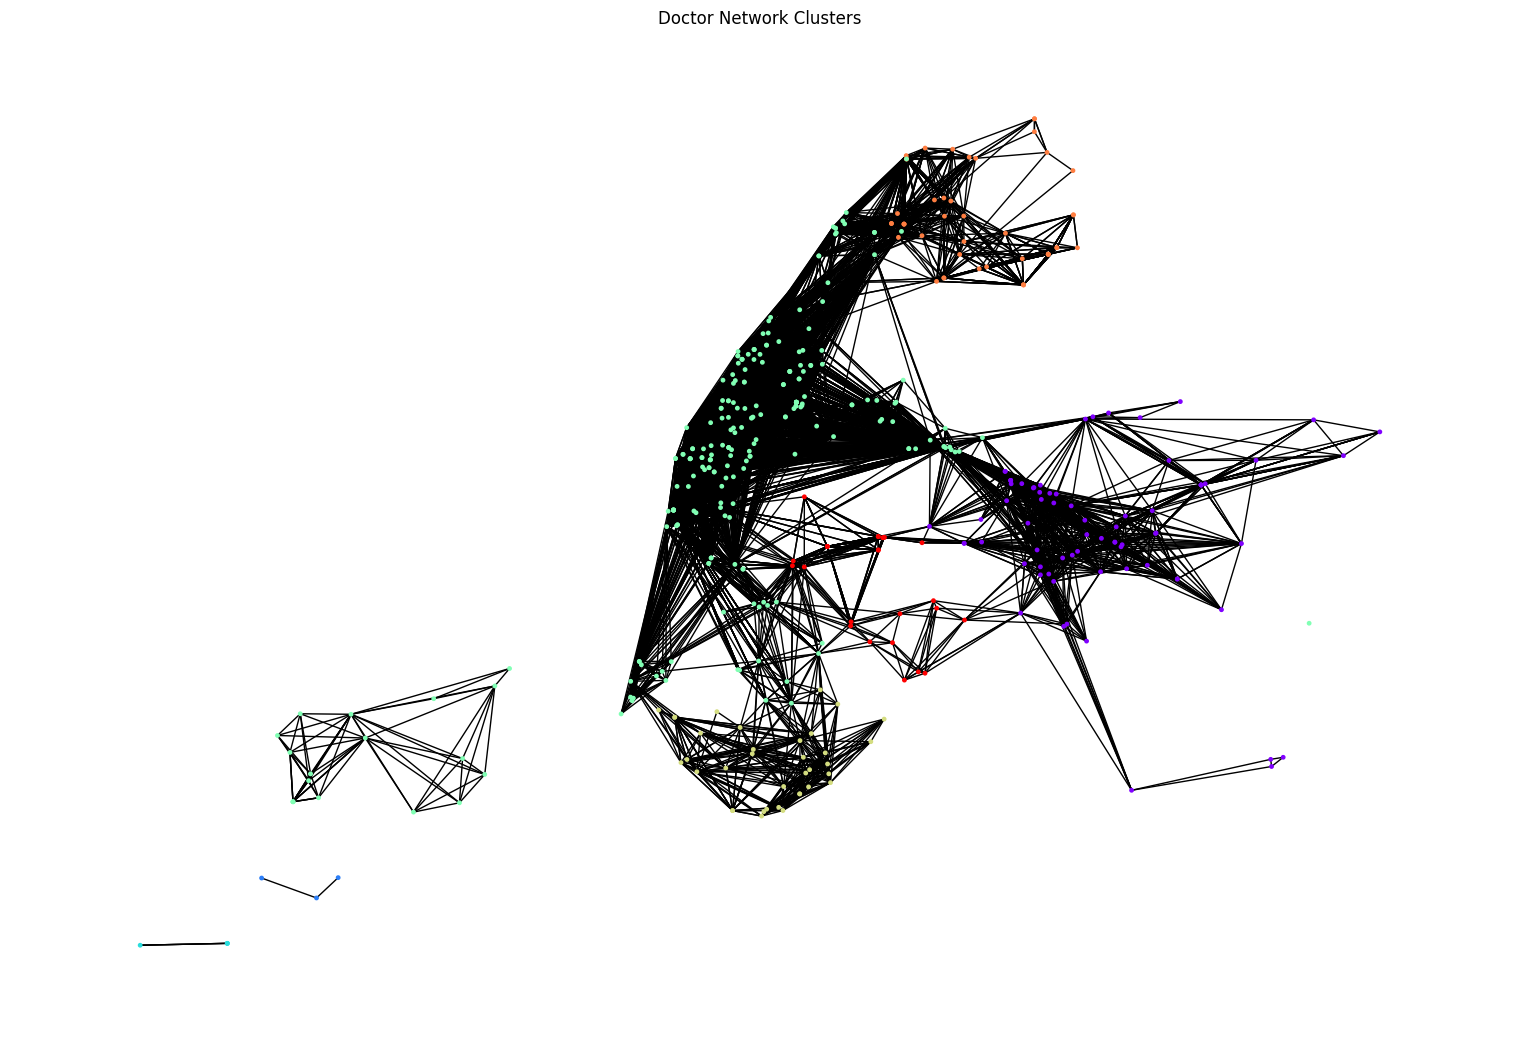

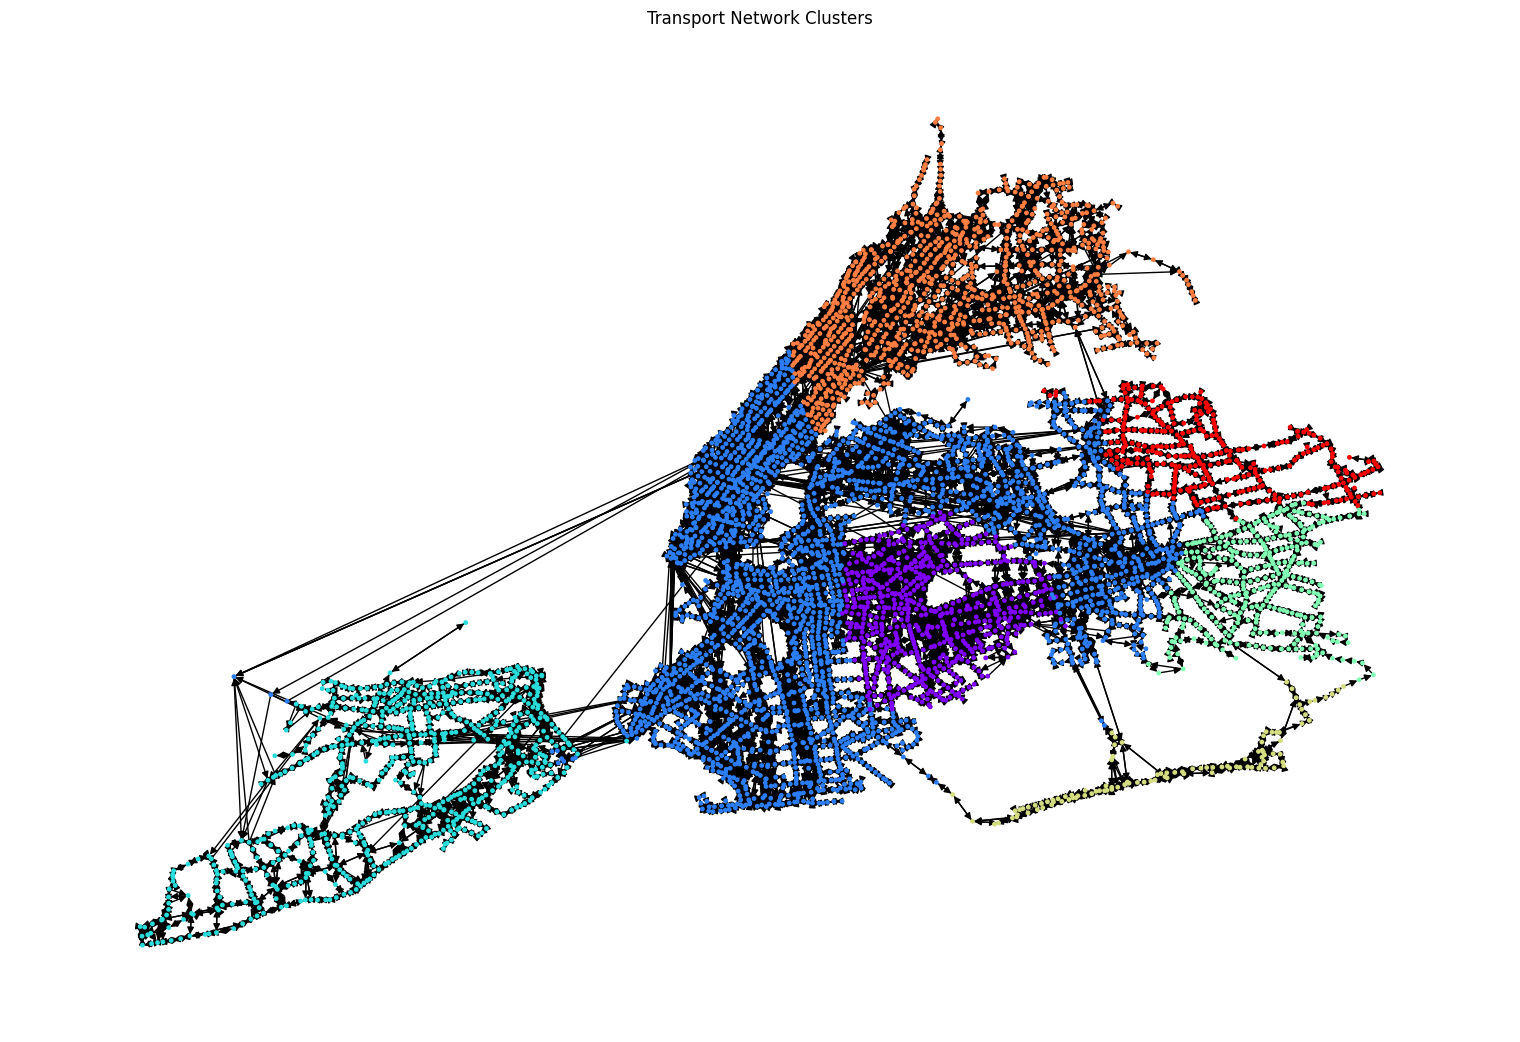

In [18]:
# Function to visualize clusters
def visualize_clusters(G, labels, title, pos):
    # pos = nx.spring_layout(G)
    plt.figure(figsize=(15, 10))
    nx.draw(G, pos=pos, with_labels=False, node_color=labels, cmap=plt.cm.rainbow, node_size=6, font_size=15, font_weight='bold')
    plt.title(title)
    plt.show()

# Visualize clusters for doctor network
visualize_clusters(G_28_4mins, labels_doctor, "Doctor Network Clusters", pos=doctors_pos)

stations_pos = nx.get_node_attributes(G_merged_weekday,'pos')
# Visualize clusters for transport network
visualize_clusters(G_merged_weekday, labels_transport, "Transport Network Clusters", pos=stations_pos)


In [19]:
from collections import Counter

# Function to compare clusters
def compare_clusters(labels1, labels2):
    counter1 = Counter(labels1)
    counter2 = Counter(labels2)
    
    print("Doctor Network Clusters:")
    for cluster, count in counter1.items():
        print(f"Cluster {cluster}: {count} nodes")
        
    print("\nTransport Network Clusters:")
    for cluster, count in counter2.items():
        print(f"Cluster {cluster}: {count} nodes")

# Compare the clusters
compare_clusters(labels_doctor, labels_transport)


Doctor Network Clusters:
Cluster 3: 241 nodes
Cluster 5: 46 nodes
Cluster 0: 74 nodes
Cluster 4: 36 nodes
Cluster 6: 28 nodes
Cluster 1: 3 nodes
Cluster 2: 4 nodes

Transport Network Clusters:
Cluster 5: 1059 nodes
Cluster 1: 2751 nodes
Cluster 0: 652 nodes
Cluster 3: 355 nodes
Cluster 4: 108 nodes
Cluster 2: 715 nodes
Cluster 6: 333 nodes


In [20]:
def find_density(G_transport, G_doctor):
    print(f'The density of the transport network is {nx.density(G_transport)}')
    print(f'The density of the doctor network is {nx.density(G_doctor)}')
    

find_density(G_merged_weekday, G_28_4mins)

The density of the transport network is 0.0009212027914406972
The density of the doctor network is 0.14872819455186045
